In [97]:
import os 

folder_path = "../data/Y29uaXRlLmdib2RvZ2JlQHVtNnAubWE=_1771257322226"
files = os.listdir(folder_path)
for root, dirs, files in os.walk(folder_path):
    print(f"\n📁 {root}")
    for f in files:
        print("   ", f)


📁 ../data/Y29uaXRlLmdib2RvZ2JlQHVtNnAubWE=_1771257322226
    readme.pdf
    output_data.gpkg
    output_data_points.csv
    hex_grid.geojson
    output_data.geojson

📁 ../data/Y29uaXRlLmdib2RvZ2JlQHVtNnAubWE=_1771257322226/OpenLandMap
    sol_texture_class_usda_tt_m_250m_b60_60cm_1950_2017_v0_2.tif
    sol_bulkdens.fineearth_usda.4a1h_m_250m_b200..200cm_1950..2017_v0.2.tif
    sol_ph.h2o_usda.4c1a2a_m_250m_b0..0cm_1950..2017_v0.2.tif
    sol_bulkdens.fineearth_usda.4a1h_m_250m_b10..10cm_1950..2017_v0.2.tif
    sol_organic.carbon_usda.6a1c_m_250m_b60..60cm_1950..2017_v0.2.tif
    sol_watercontent.1500kPa_usda.3c2a1a_m_250m_b0..0cm_1950..2017_v0.1.tif
    sol_bulkdens.fineearth_usda.4a1h_m_250m_b60..60cm_1950..2017_v0.2.tif
    sol_organic.carbon.stock_msa.kgm2_m_250m_b100..200cm_1950..2017_v0.2.tif
    sol_coarsefrag.vfraction_usda.3b1_m_250m_b30..30cm_1950..2017_v0.2.tif
    sol_bulkdens.fineearth_usda.4a1h_m_250m_b30..30cm_1950..2017_v0.2.tif
    sol_sand.wfraction_usda.3a1a1a_m_250m

In [98]:
import os
import rasterio
import pandas as pd

def explore_raster_directories(base_path, recursive=True):
    """
    Parcourt tous les dossiers contenant des rasters (.tif)
    et retourne un DataFrame résumant leurs métadonnées.
    
    Parameters:
        base_path (str): chemin racine contenant les dossiers raster
        recursive (bool): parcourir les sous-dossiers
    
    Returns:
        pd.DataFrame
    """
    
    raster_info = []

    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(".tif"):
                filepath = os.path.join(root, file)
                
                try:
                    with rasterio.open(filepath) as src:
                        raster_info.append({
                            "source_folder": os.path.basename(root),
                            "file_name": file,
                            "crs": str(src.crs),
                            "resolution_x": src.res[0],
                            "resolution_y": src.res[1],
                            "width": src.width,
                            "height": src.height,
                            "count_bands": src.count,
                            "dtype": src.dtypes[0],
                            "nodata": src.nodata
                        })
                except Exception as e:
                    print(f"Erreur lecture {file}: {e}")

        if not recursive:
            break

    df_rasters = pd.DataFrame(raster_info)
    
    if len(df_rasters) == 0:
        print("Aucun raster trouvé.")
    else:
        print(f"Total rasters trouvés: {len(df_rasters)}")
    
    return df_rasters

AFSIS

In [99]:
afsis_path = "../data/Y29uaXRlLmdib2RvZ2JlQHVtNnAubWE=_1771257322226/AfSIS_Property_maps"
df_rasters_afsis = explore_raster_directories(afsis_path)
display(df_rasters_afsis.head())

Total rasters trouvés: 73


,source_folder,file_name,crs,resolution_x,resolution_y,width,height,count_bands,dtype,nodata
0,AfSIS_Property_maps,af_PHIHOX_T__M_s_30_60_cm_250m.tif,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1...",0.002409,0.002409,7251,4107,1,float32,-9999.0
1,AfSIS_Property_maps,af_CLYPPT_T__M_s_0_5_cm_250m.tif,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1...",0.002409,0.002409,7251,4107,1,float32,-9999.0
2,AfSIS_Property_maps,af_ALUM3S_T__M_x_0_20_cm_250m.tif,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1...",0.002409,0.002409,7251,4107,1,float32,-9999.0
3,AfSIS_Property_maps,af_ORCDRC_T__M_s_60_100_cm_250m.tif,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1...",0.002409,0.002409,7251,4107,1,float32,-9999.0
4,AfSIS_Property_maps,af_ORCDRC_T__M_s_0_5_cm_250m.tif,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1...",0.002409,0.002409,7251,4107,1,float32,-9999.0


GSOCmap

In [100]:
gsoc_path = "../data/Y29uaXRlLmdib2RvZ2JlQHVtNnAubWE=_1771257322226/GSOCmap"
df_rasters_gsoc = explore_raster_directories(gsoc_path)
display(df_rasters_gsoc.head())

Total rasters trouvés: 1


,source_folder,file_name,crs,resolution_x,resolution_y,width,height,count_bands,dtype,nodata
0,GSOCmap,GSOCmap1.5.0.tif,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1...",0.008333,0.008333,2702,1939,1,float32,-9999.0


OpenLandMap

In [101]:
openlandmap_path = "../data/Y29uaXRlLmdib2RvZ2JlQHVtNnAubWE=_1771257322226/OpenLandMap"
df_rasters_openlandmap = explore_raster_directories(openlandmap_path)
display(df_rasters_openlandmap.head())


Total rasters trouvés: 59


,source_folder,file_name,crs,resolution_x,resolution_y,width,height,count_bands,dtype,nodata
0,OpenLandMap,sol_texture_class_usda_tt_m_250m_b60_60cm_1950...,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1...",0.002083,0.002083,10803,7754,1,int16,-9999.0
1,OpenLandMap,sol_bulkdens.fineearth_usda.4a1h_m_250m_b200.....,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1...",0.002083,0.002083,10803,7754,1,int16,-9999.0
2,OpenLandMap,sol_ph.h2o_usda.4c1a2a_m_250m_b0..0cm_1950..20...,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1...",0.002083,0.002083,10803,7754,1,int16,-9999.0
3,OpenLandMap,sol_bulkdens.fineearth_usda.4a1h_m_250m_b10..1...,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1...",0.002083,0.002083,10803,7754,1,int16,-9999.0
4,OpenLandMap,sol_organic.carbon_usda.6a1c_m_250m_b60..60cm_...,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1...",0.002083,0.002083,10803,7754,1,int16,-9999.0


GeoPackage

In [102]:
%pip install fiona --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [103]:

import fiona

gpkg_path = os.path.join(base_path, "output_data.gpkg")
if os.path.exists(gpkg_path):
    layers = fiona.listlayers(gpkg_path)
    print("\n🗺 output_data.gpkg layers:", layers)

    for layer in layers:
        gdf = gpd.read_file(gpkg_path, layer=layer)
        print(f"\nLayer: {layer}")
        print("Shape:", gdf.shape)
        print("Columns:", gdf.columns.tolist())
        display(gdf.head())


🗺 output_data.gpkg layers: ['points']

Layer: points
Shape: (10184, 13)
Columns: ['id', 'h3_index', 'property', 'original_name', 'sampling_date', 'publication_date', 'upper_depth_cm', 'lower_depth_cm', 'value', 'unit', 'data_source', 'license', 'geometry']


,id,h3_index,property,original_name,sampling_date,publication_date,upper_depth_cm,lower_depth_cm,value,unit,data_source,license,geometry
0,1,83344cfffffffff,TC,totc,,2023-01-01,0,20,5.8,g/kg,WoSIS,CC BY 4.0,POINT (-15.55556 27.92425)
1,2,83344cfffffffff,TC,totc,,2023-01-01,0,20,18.4,g/kg,WoSIS,CC BY 4.0,POINT (-15.56609 27.96442)
2,3,83344cfffffffff,TC,totc,,2023-01-01,0,20,2.0,g/kg,WoSIS,CC BY 4.0,POINT (-15.45288 27.8264)
3,4,83344cfffffffff,CEC,cecph7,1975,2023-01-01,60,120,31.9,cmolc/kg,WoSIS,US Public Domain,POINT (-16.5 28.3333)
4,5,83344cfffffffff,CEC,cecph7,1975,2023-01-01,40,60,48.9,cmolc/kg,WoSIS,US Public Domain,POINT (-16.5 28.3333)


Hex grid

In [104]:
import geopandas as gpd
import pandas as pd

gpkg_path = "../data/Y29uaXRlLmdib2RvZ2JlQHVtNnAubWE=_1771257322226/output_data.gpkg"
csv_path  = "../data/Y29uaXRlLmdib2RvZ2JlQHVtNnAubWE=_1771257322226/output_data_points.csv"

gdf = gpd.read_file(gpkg_path, layer="points")
df_csv = pd.read_csv(csv_path)

In [105]:
df_csv

,id,lat,lon,property,original_name,upper_depth_cm,lower_depth_cm,value,unit,sampling_date,license,h3_index,publication_date,data_source
0,1,27.924248,-15.555563,TC,totc,0.0,20.0,5.8,g/kg,NaN,CC BY 4.0,83344cfffffffff,2023-01-01,WoSIS
1,2,27.964420,-15.566089,TC,totc,0.0,20.0,18.4,g/kg,NaN,CC BY 4.0,83344cfffffffff,2023-01-01,WoSIS
2,3,27.826397,-15.452883,TC,totc,0.0,20.0,2.0,g/kg,NaN,CC BY 4.0,83344cfffffffff,2023-01-01,WoSIS
3,4,28.333300,-16.500000,CEC,cecph7,60.0,120.0,31.9,cmolc/kg,1975.0,US Public Domain,83344cfffffffff,2023-01-01,WoSIS
4,5,28.333300,-16.500000,CEC,cecph7,40.0,60.0,48.9,cmolc/kg,1975.0,US Public Domain,83344cfffffffff,2023-01-01,WoSIS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10179,2985,39.485298,2.817800,TC,totc,0.0,20.0,23.3,g/kg,NaN,CC BY 4.0,83395cfffffffff,2023-01-01,WoSIS
10180,2986,39.550800,3.261400,pH,phca,0.0,20.0,7.3,NaN,NaN,CC BY 4.0,83395cfffffffff,2023-01-01,WoSIS
10181,2987,39.550800,3.261400,silt,silt,0.0,20.0,28.0,g/100g,NaN,CC BY 4.0,83395cfffffffff,2023-01-01,WoSIS
10182,2988,39.550800,3.261400,clay,clay,0.0,20.0,8.0,g/100g,NaN,CC BY 4.0,83395cfffffffff,2023-01-01,WoSIS


In [106]:
df_csv.columns

Index(['id', 'lat', 'lon', 'property', 'original_name', 'upper_depth_cm',
       'lower_depth_cm', 'value', 'unit', 'sampling_date', 'license',
       'h3_index', 'publication_date', 'data_source'],
      dtype='object')

In [107]:
df_csv['property'].unique()

array(['TC', 'CEC', 'sand', 'BD', 'CF', 'silt', 'pH', 'clay', 'CaCO3',
       'N', 'occ', 'P', 'EC', 'WR_gravimetric', 'WR_volumetric', 'Na',
       'Mg', 'K', 'Ca', 'nematode'], dtype=object)

In [108]:
# remove df_csv['property'] == 'nematode'
df_csv = df_csv[df_csv['property'] != 'nematode']

In [109]:
df_csv["sampling_date"].unique()

array([  nan, 1975., 1982., 1970., 2014., 1974., 1984., 1968., 1951.,
       2010., 2011., 1980., 1994., 2006., 1983.])

In [110]:
unique_points = df_csv[["lat", "lon"]].drop_duplicates()
print("Nombre de points uniques :", unique_points.shape[0])

Nombre de points uniques : 830


Nb observations par point

In [111]:
points_counts = (
    df_csv
    .groupby(["lat", "lon"])
    .size()
    .reset_index(name="n_observations")
    .sort_values(by="n_observations", ascending=False)
)
print(points_counts.head())

           lat        lon  n_observations
242  38.800000  -6.433333             214
228  38.750000  -6.500000             209
8    28.333300 -16.500000             208
248  38.850000  -6.450000             203
266  38.916667  -6.166667             182


Features by points

In [112]:
properties_per_point = (
    df_csv
    .groupby(["lat", "lon"])["property"]
    .nunique()
    .reset_index(name="n_properties")
    .sort_values(by="n_properties", ascending=False)
)

print(properties_per_point.head())

           lat       lon  n_properties
228  38.750000 -6.500000            13
635  42.142222 -2.502222            13
270  38.950000 -6.300000            13
592  41.863056 -0.558056            13
248  38.850000 -6.450000            13


Fonction d’exploration d’un point

In [113]:
def explore_point(df, lat, lon):
    point_df = df[
        (df["lat"] == lat) &
        (df["lon"] == lon)
    ].copy()

    props_with_date = (
        point_df[point_df["sampling_date"].notna()]
        ["property"]
        .unique()
    )
    print("Propriétés AVEC date :")
    print(props_with_date)
    props_without_date = (
    point_df[point_df["sampling_date"].isna()]
        ["property"]
        .unique()
    )
    print("\nPropriétés SANS date :")
    print(props_without_date)

    if point_df.empty:
        print("Aucune donnée pour ce point.")
        return
    
    print(f"\nPoint ({lat}, {lon})")
    print("Nombre total d'observations :", len(point_df))
    print("Nombre de propriétés uniques :", point_df["property"].nunique())
    print("Dates uniques :", point_df["sampling_date"].unique())
    
    display(
        point_df[[
            "property",
            "upper_depth_cm",
            "lower_depth_cm",
            "sampling_date",
            "value"
        ]].sort_values(["property", "upper_depth_cm"])
    )
    return point_df

point_df = explore_point(df_csv, 38.750000, -6.500000)

Propriétés AVEC date :
['CEC' 'sand' 'CaCO3' 'pH' 'silt' 'EC' 'N' 'occ' 'clay']

Propriétés SANS date :
['CEC' 'sand' 'Na' 'pH' 'Mg' 'silt' 'K' 'occ' 'Ca' 'EC' 'clay']

Point (38.75, -6.5)
Nombre total d'observations : 209
Nombre de propriétés uniques : 13
Dates uniques : [1970.   nan]


,property,upper_depth_cm,lower_depth_cm,sampling_date,value
1967,CEC,0.0,10.0,1970.0,44.40000
4745,CEC,0.0,10.0,1970.0,44.40000
1965,CEC,10.0,25.0,1970.0,44.50000
4742,CEC,10.0,25.0,1970.0,44.50000
1969,CEC,25.0,50.0,1970.0,44.50000
...,...,...,...,...,...
6597,silt,NaN,NaN,NaN,26.40625
6608,silt,NaN,NaN,NaN,28.50000
6628,silt,NaN,NaN,NaN,29.09375
6637,silt,NaN,NaN,NaN,33.00000


In [114]:
summary_df = (
    point_df
    .groupby("property")
    .agg(
        n_obs=("value", "count"),
        with_date=("sampling_date", lambda x: x.notna().sum()),
        without_date=("sampling_date", lambda x: x.isna().sum()),
        min_depth=("upper_depth_cm", "min"),
        max_depth=("lower_depth_cm", "max")
    )
    .reset_index()
)

summary_df

,property,n_obs,with_date,without_date,min_depth,max_depth
0,CEC,20,14,6,0.0,130.0
1,Ca,7,0,7,NaN,NaN
2,CaCO3,14,14,0,0.0,130.0
3,EC,19,14,5,0.0,130.0
4,K,4,0,4,NaN,NaN
5,Mg,7,0,7,NaN,NaN
6,N,14,14,0,0.0,130.0
7,Na,1,0,1,NaN,NaN
8,clay,21,14,7,0.0,130.0
9,occ,21,14,7,0.0,130.0


Explorer les valeurs détaillées par propriété

In [115]:
for prop in point_df["property"].unique():
    print(f"\nPropriété: {prop}")
    display(
        point_df[point_df["property"] == prop].sort_values("upper_depth_cm")
    )


  


Propriété: CEC


,id,lat,lon,property,original_name,upper_depth_cm,lower_depth_cm,value,unit,sampling_date,license,h3_index,publication_date,data_source
1967,1968,38.75,-6.5,CEC,cecph7,0.0,10.0,44.40000,cmolc/kg,1970.0,CC BY 3.0,833902fffffffff,2023-01-01,WoSIS
4745,2713,38.75,-6.5,CEC,cecph7,0.0,10.0,44.40000,cmolc/kg,1970.0,CC BY 4.0,833902fffffffff,2023-01-01,WoSIS
4742,2710,38.75,-6.5,CEC,cecph7,10.0,25.0,44.50000,cmolc/kg,1970.0,CC BY 4.0,833902fffffffff,2023-01-01,WoSIS
1965,1966,38.75,-6.5,CEC,cecph7,10.0,25.0,44.50000,cmolc/kg,1970.0,CC BY 3.0,833902fffffffff,2023-01-01,WoSIS
1969,1970,38.75,-6.5,CEC,cecph7,25.0,50.0,44.50000,cmolc/kg,1970.0,CC BY 3.0,833902fffffffff,2023-01-01,WoSIS
4746,2714,38.75,-6.5,CEC,cecph7,25.0,50.0,44.50000,cmolc/kg,1970.0,CC BY 4.0,833902fffffffff,2023-01-01,WoSIS
4744,2712,38.75,-6.5,CEC,cecph7,50.0,70.0,38.30000,cmolc/kg,1970.0,CC BY 4.0,833902fffffffff,2023-01-01,WoSIS
1968,1969,38.75,-6.5,CEC,cecph7,50.0,70.0,38.30000,cmolc/kg,1970.0,CC BY 3.0,833902fffffffff,2023-01-01,WoSIS
4740,2708,38.75,-6.5,CEC,cecph7,70.0,90.0,34.90000,cmolc/kg,1970.0,CC BY 4.0,833902fffffffff,2023-01-01,WoSIS
1963,1964,38.75,-6.5,CEC,cecph7,70.0,90.0,34.90000,cmolc/kg,1970.0,CC BY 3.0,833902fffffffff,2023-01-01,WoSIS



Propriété: sand


,id,lat,lon,property,original_name,upper_depth_cm,lower_depth_cm,value,unit,sampling_date,license,h3_index,publication_date,data_source
1974,1975,38.75,-6.5,sand,sand,0.0,10.0,21.000000,g/100g,1970.0,CC BY 3.0,833902fffffffff,2023-01-01,WoSIS
4752,2720,38.75,-6.5,sand,sand,0.0,10.0,20.900000,g/100g,1970.0,CC BY 4.0,833902fffffffff,2023-01-01,WoSIS
4749,2717,38.75,-6.5,sand,sand,10.0,25.0,21.000000,g/100g,1970.0,CC BY 4.0,833902fffffffff,2023-01-01,WoSIS
1972,1973,38.75,-6.5,sand,sand,10.0,25.0,21.000000,g/100g,1970.0,CC BY 3.0,833902fffffffff,2023-01-01,WoSIS
1976,1977,38.75,-6.5,sand,sand,25.0,50.0,20.000000,g/100g,1970.0,CC BY 3.0,833902fffffffff,2023-01-01,WoSIS
4753,2721,38.75,-6.5,sand,sand,25.0,50.0,20.400000,g/100g,1970.0,CC BY 4.0,833902fffffffff,2023-01-01,WoSIS
4751,2719,38.75,-6.5,sand,sand,50.0,70.0,19.200000,g/100g,1970.0,CC BY 4.0,833902fffffffff,2023-01-01,WoSIS
1975,1976,38.75,-6.5,sand,sand,50.0,70.0,19.000000,g/100g,1970.0,CC BY 3.0,833902fffffffff,2023-01-01,WoSIS
4747,2715,38.75,-6.5,sand,sand,70.0,90.0,20.100000,g/100g,1970.0,CC BY 4.0,833902fffffffff,2023-01-01,WoSIS
1970,1971,38.75,-6.5,sand,sand,70.0,90.0,20.000000,g/100g,1970.0,CC BY 3.0,833902fffffffff,2023-01-01,WoSIS



Propriété: CaCO3


...

,id,lat,lon,property,original_name,upper_depth_cm,lower_depth_cm,value,unit,sampling_date,license,h3_index,publication_date,data_source
6586,4554,38.75,-6.5,Mg,soil_Mg,NaN,NaN,7.699219,mg/kg,NaN,CC BY 4.0,833902fffffffff,2024-01-01,CAROB
6596,4564,38.75,-6.5,Mg,soil_Mg,NaN,NaN,8.601562,mg/kg,NaN,CC BY 4.0,833902fffffffff,2024-01-01,CAROB
6607,4575,38.75,-6.5,Mg,soil_Mg,NaN,NaN,9.101562,mg/kg,NaN,CC BY 4.0,833902fffffffff,2024-01-01,CAROB
6618,4586,38.75,-6.5,Mg,soil_Mg,NaN,NaN,8.203125,mg/kg,NaN,CC BY 4.0,833902fffffffff,2024-01-01,CAROB
6627,4595,38.75,-6.5,Mg,soil_Mg,NaN,NaN,6.898438,mg/kg,NaN,CC BY 4.0,833902fffffffff,2024-01-01,CAROB
6636,4604,38.75,-6.5,Mg,soil_Mg,NaN,NaN,8.296875,mg/kg,NaN,CC BY 4.0,833902fffffffff,2024-01-01,CAROB
6644,4612,38.75,-6.5,Mg,soil_Mg,NaN,NaN,9.203125,mg/kg,NaN,CC BY 4.0,833902fffffffff,2024-01-01,CAROB



Propriété: K


,id,lat,lon,property,original_name,upper_depth_cm,lower_depth_cm,value,unit,sampling_date,license,h3_index,publication_date,data_source
6588,4556,38.75,-6.5,K,soil_K,NaN,NaN,0.700195,mg/kg,NaN,CC BY 4.0,833902fffffffff,2024-01-01,CAROB
6598,4566,38.75,-6.5,K,soil_K,NaN,NaN,0.500000,mg/kg,NaN,CC BY 4.0,833902fffffffff,2024-01-01,CAROB
6609,4577,38.75,-6.5,K,soil_K,NaN,NaN,0.399902,mg/kg,NaN,CC BY 4.0,833902fffffffff,2024-01-01,CAROB
6619,4587,38.75,-6.5,K,soil_K,NaN,NaN,1.000000,mg/kg,NaN,CC BY 4.0,833902fffffffff,2024-01-01,CAROB



Propriété: Ca


,id,lat,lon,property,original_name,upper_depth_cm,lower_depth_cm,value,unit,sampling_date,license,h3_index,publication_date,data_source
6590,4558,38.75,-6.5,Ca,soil_Ca,NaN,NaN,34.906250,mg/kg,NaN,CC BY 4.0,833902fffffffff,2024-01-01,CAROB
6600,4568,38.75,-6.5,Ca,soil_Ca,NaN,NaN,33.812500,mg/kg,NaN,CC BY 4.0,833902fffffffff,2024-01-01,CAROB
6611,4579,38.75,-6.5,Ca,soil_Ca,NaN,NaN,31.000000,mg/kg,NaN,CC BY 4.0,833902fffffffff,2024-01-01,CAROB
6621,4589,38.75,-6.5,Ca,soil_Ca,NaN,NaN,34.812500,mg/kg,NaN,CC BY 4.0,833902fffffffff,2024-01-01,CAROB
6630,4598,38.75,-6.5,Ca,soil_Ca,NaN,NaN,20.093750,mg/kg,NaN,CC BY 4.0,833902fffffffff,2024-01-01,CAROB
6639,4607,38.75,-6.5,Ca,soil_Ca,NaN,NaN,22.296875,mg/kg,NaN,CC BY 4.0,833902fffffffff,2024-01-01,CAROB
6647,4615,38.75,-6.5,Ca,soil_Ca,NaN,NaN,27.796875,mg/kg,NaN,CC BY 4.0,833902fffffffff,2024-01-01,CAROB


For the same points, we have 2 sources. One source dont have

In [116]:
def summarize_points(df):

    summary = (
        df
        .groupby(["lat", "lon"])
        .agg(
            n_obs=("value", "count"),
            n_properties=("property", "nunique"),
            properties=("property", lambda x: sorted(x.unique())),
            n_sources=("data_source", "nunique"),
            sources=("data_source", lambda x: sorted(x.unique())),
            n_dates=("sampling_date", lambda x: x.notna().sum()),
            unique_dates=("sampling_date", lambda x: sorted(x.dropna().unique())),
            n_unique_dates=("sampling_date", "nunique"),
            n_depth_combinations=("upper_depth_cm", "count")
        )
        .reset_index()
        .sort_values("n_obs", ascending=False)
    )

    return summary

point_summary = summarize_points(df_csv)
point_summary.head(20)

,lat,lon,n_obs,n_properties,properties,n_sources,sources,n_dates,unique_dates,n_unique_dates,n_depth_combinations
242,38.800000,-6.433333,214,10,"[CEC, CF, CaCO3, EC, N, clay, occ, pH, sand, s...",1,[WoSIS],214,"[1970.0, 1974.0]",2,214
228,38.750000,-6.500000,209,13,"[CEC, Ca, CaCO3, EC, K, Mg, N, Na, clay, occ, ...",2,"[CAROB, WoSIS]",140,[1970.0],1,140
8,28.333300,-16.500000,208,6,"[BD, CEC, CF, TC, sand, silt]",1,[WoSIS],208,[1975.0],1,208
248,38.850000,-6.450000,203,13,"[CEC, Ca, CaCO3, EC, K, Mg, N, Na, clay, occ, ...",2,"[CAROB, WoSIS]",140,[1974.0],1,140
266,38.916667,-6.166667,182,9,"[CEC, CaCO3, EC, N, clay, occ, pH, sand, silt]",1,[WoSIS],182,[1974.0],1,182
245,38.800000,-6.366667,162,10,"[CEC, CF, CaCO3, EC, N, clay, occ, pH, sand, s...",1,[WoSIS],162,[1970.0],1,162
570,41.738889,1.369444,143,10,"[BD, CEC, CaCO3, EC, WR_volumetric, clay, occ,...",1,[WoSIS],143,[1984.0],1,143
259,38.900000,-6.333333,133,9,"[CEC, CF, CaCO3, EC, N, clay, occ, pH, silt]",1,[WoSIS],133,[1970.0],1,133
270,38.950000,-6.300000,129,13,"[CEC, CF, Ca, CaCO3, EC, K, Mg, N, Na, clay, o...",2,"[CAROB, WoSIS]",82,[1970.0],1,82
635,42.142222,-2.502222,115,13,"[BD, CEC, CF, CaCO3, EC, N, P, TC, WR_gravimet...",1,[WoSIS],115,[2010.0],1,115


**Hypothèse : Les données provenant de la source CAROB n’ont pas :**

* de sampling_date
* ni de upper_depth_cm
* ni de lower_depth_cm

1. Separate CAROB vs other sources

In [117]:
carob_df = df_csv[df_csv["data_source"] == "CAROB"].copy()
wosis_df = df_csv[df_csv["data_source"] == "WoSIS"].copy()

2. Check date presence

In [118]:
summary_source = (
    df_csv
    .groupby("data_source")
    .agg(
        n_obs=("value", "count"),
        pct_date_present=("sampling_date", lambda x: x.notna().mean()*100),
        pct_upper_depth_present=("upper_depth_cm", lambda x: x.notna().mean()*100),
        pct_lower_depth_present=("lower_depth_cm", lambda x: x.notna().mean()*100)
    )
    .reset_index()
)

summary_source

,data_source,n_obs,pct_date_present,pct_upper_depth_present,pct_lower_depth_present
0,CAROB,983,0.000000,0.0,0.0
1,WoSIS,6534,65.212733,100.0,100.0


CAROB
* Aucune date

* Aucune profondeur

* Valeurs présentes

* 983 observations

Ce sont données dérivées / harmonisées / interpolées

WoSIS

* Profondeur toujours renseignée

* Date seulement dans 65% des cas

* 6534 observations

Ce sont mesures terrain réelles.

`Les données CAROB n'ont ni date ni profondeur.`

Details about one point to try to understand 35%

In [121]:
lat0 = 38.75
lon0 = -6.5

point_wosis = df_csv[
    (df_csv["lat"] == lat0) &
    (df_csv["lon"] == lon0) &
    (df_csv["data_source"] == "WoSIS")
].copy()

with_date = point_wosis[point_wosis["sampling_date"].notna()]
without_date = point_wosis[point_wosis["sampling_date"].isna()]

print("Point :", (lat0, lon0))
print("Total WoSIS obs :", len(point_wosis))
print("Avec date :", len(with_date))
print("Sans date :", len(without_date))

print("\nPropriétés AVEC date :", with_date["property"].unique())
print("Propriétés SANS date :", without_date["property"].unique())

Point : (38.75, -6.5)
Total WoSIS obs : 140
Avec date : 140
Sans date : 0

Propriétés AVEC date : ['CEC' 'sand' 'CaCO3' 'pH' 'silt' 'EC' 'N' 'occ' 'clay']
Propriétés SANS date : []


In [124]:
wosis_df = df_csv[df_csv["data_source"] == "WoSIS"].copy()
def summarize_wosis_dates(df):

    summary = (
        df
        .groupby(["lat", "lon"])
        .apply(lambda g: pd.Series({
            "n_obs": len(g),
            "n_with_date": g["sampling_date"].notna().sum(),
            "n_without_date": g["sampling_date"].isna().sum(),
            "properties_with_date": sorted(
                g[g["sampling_date"].notna()]["property"].unique()
            ),
            "properties_without_date": sorted(
                g[g["sampling_date"].isna()]["property"].unique()
            )
        }))
        .reset_index()
        .sort_values("n_obs", ascending=False)
    )

    return summary

wosis_summary = summarize_wosis_dates(wosis_df)
wosis_summary

/tmp/ipykernel_102647/2381464436.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,lat,lon,n_obs,n_with_date,n_without_date,properties_with_date,properties_without_date
239,38.800000,-6.433333,214,214,0,"[CEC, CF, CaCO3, EC, N, clay, occ, pH, sand, s...",[]
8,28.333300,-16.500000,208,208,0,"[BD, CEC, CF, TC, sand, silt]",[]
256,38.916667,-6.166667,182,182,0,"[CEC, CaCO3, EC, N, clay, occ, pH, sand, silt]",[]
240,38.800000,-6.366667,162,162,0,"[CEC, CF, CaCO3, EC, N, clay, occ, pH, sand, s...",[]
555,41.738889,1.369444,143,143,0,"[BD, CEC, CaCO3, EC, WR_volumetric, clay, occ,...",[]
...,...,...,...,...,...,...,...
784,43.134441,-1.546458,1,0,1,[],[TC]
785,43.142467,-1.567370,1,0,1,[],[TC]
786,43.142971,-6.584736,1,0,1,[],[TC]
788,43.175629,-2.912483,1,0,1,[],[TC]


In [125]:
wosis_summary[
    wosis_summary["n_with_date"] == 0
].copy()


,lat,lon,n_obs,n_with_date,n_without_date,properties_with_date,properties_without_date
354,39.916698,-5.583300,19,0,19,[],"[clay, occ, sand]"
505,41.366699,-3.500000,15,0,15,[],"[clay, occ, sand]"
131,37.818298,-0.953300,15,0,15,[],"[clay, occ, sand]"
398,40.333302,-5.666700,15,0,15,[],"[clay, occ, sand]"
201,38.583302,-6.500000,14,0,14,[],"[clay, occ, sand]"
...,...,...,...,...,...,...,...
784,43.134441,-1.546458,1,0,1,[],[TC]
785,43.142467,-1.567370,1,0,1,[],[TC]
786,43.142971,-6.584736,1,0,1,[],[TC]
788,43.175629,-2.912483,1,0,1,[],[TC]


In [142]:
coords = wosis_summary[wosis_summary["n_with_date"] == 0][["lat", "lon"]]


In WoSIS, they have points that have date and not. 

1. Separating the two groups

In [143]:
wosis_df = df_csv[df_csv["data_source"] == "WoSIS"].copy()
with_date_df = wosis_df[wosis_df["sampling_date"].notna()].copy()
without_date_df = wosis_df[wosis_df["sampling_date"].isna()].copy()

points_with_date = with_date_df[["lat", "lon"]].drop_duplicates().reset_index(drop=True)
points_without_date = without_date_df[["lat", "lon"]].drop_duplicates().reset_index(drop=True)

print("Points avec date :", len(points_with_date))
print("Points sans date :", len(points_without_date))

Points avec date : 80
Points sans date : 734


2. Function geographical distance && Find the nearest neighbor

In [146]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def find_nearest_with_date(point_row, points_with_date_df):
    
    lat0 = point_row["lat"]
    lon0 = point_row["lon"]
    
    distances = haversine(
        lat0,
        lon0,
        points_with_date_df["lat"].values,
        points_with_date_df["lon"].values
    )
    
    min_idx = np.argmin(distances)
    
    return pd.Series({
        "nearest_lat": points_with_date_df.iloc[min_idx]["lat"],
        "nearest_lon": points_with_date_df.iloc[min_idx]["lon"],
        "distance_km": distances[min_idx]
    })

nearest_results = points_without_date.apply(
    lambda row: find_nearest_with_date(row, points_with_date),
    axis=1
)

analysis_df = pd.concat([points_without_date, nearest_results], axis=1)

analysis_df.head()

,lat,lon,nearest_lat,nearest_lon,distance_km
0,27.924248,-15.555563,28.5,-16.25,93.427212
1,27.964420,-15.566089,28.5,-16.25,89.641883
2,27.826397,-15.452883,28.5,-16.25,108.241154
3,28.474199,-16.343300,28.5,-16.25,9.559050
4,28.474199,-16.344400,28.5,-16.25,9.661703


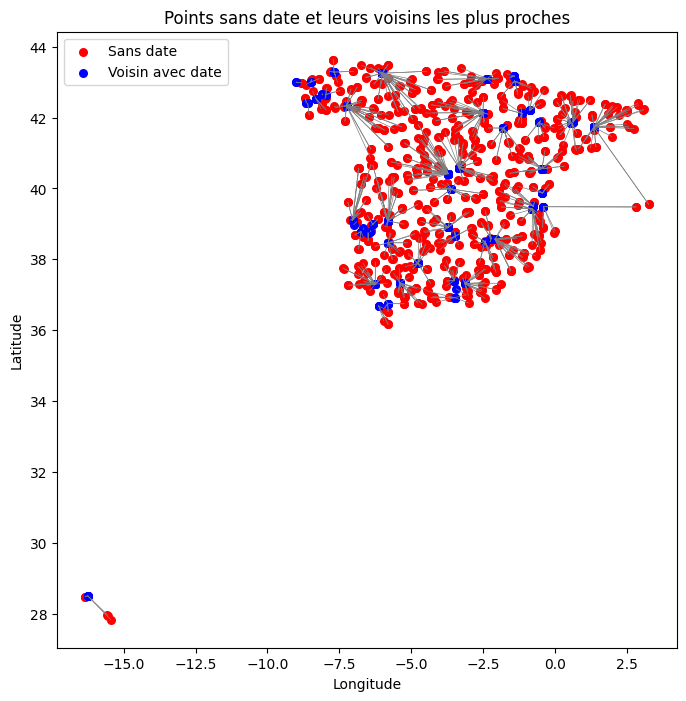

In [147]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

# Points sans date (rouge)
plt.scatter(
    analysis_df["lon"],
    analysis_df["lat"],
    color="red",
    label="Sans date",
    s=30
)

# Points voisins avec date (bleu)
plt.scatter(
    analysis_df["nearest_lon"],
    analysis_df["nearest_lat"],
    color="blue",
    label="Voisin avec date",
    s=30
)

# Lignes reliant les points
for i in range(len(analysis_df)):
    plt.plot(
        [analysis_df.iloc[i]["lon"], analysis_df.iloc[i]["nearest_lon"]],
        [analysis_df.iloc[i]["lat"], analysis_df.iloc[i]["nearest_lat"]],
        color="gray",
        linewidth=0.5
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Points sans date et leurs voisins les plus proches")
plt.legend()
plt.show()

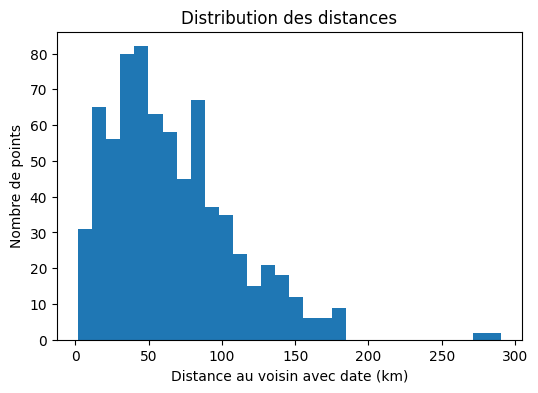

In [148]:
plt.figure(figsize=(6,4))
plt.hist(analysis_df["distance_km"], bins=30)
plt.xlabel("Distance au voisin avec date (km)")
plt.ylabel("Nombre de points")
plt.title("Distribution des distances")
plt.show()

* Points très proches (< 10 km)
* Distance modérée (10–50 km)
* Distance grande (> 50–100 km)

In [150]:
import folium

m = folium.Map(location=[analysis_df["lat"].mean(),
                         analysis_df["lon"].mean()],
               zoom_start=6)

for _, row in analysis_df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=4,
        color="red",
        fill=True
    ).add_to(m)

    folium.CircleMarker(
        location=[row["nearest_lat"], row["nearest_lon"]],
        radius=4,
        color="blue",
        fill=True
    ).add_to(m)

m

Find one point  without date, 

In [154]:
# Trouver le point sans date le plus proche d’un point avec date
closest_pair = analysis_df.sort_values("distance_km").iloc[0]
closest_pair

lat            38.474400
lon            -5.781100
nearest_lat    38.466667
nearest_lon    -5.800000
distance_km     1.856535
Name: 634, dtype: float64

In [155]:
lat_no_date = closest_pair["lat"]
lon_no_date = closest_pair["lon"]

lat_with_date = closest_pair["nearest_lat"]
lon_with_date = closest_pair["nearest_lon"]

distance = closest_pair["distance_km"]

print("Point sans date :", lat_no_date, lon_no_date)
print("Voisin avec date :", lat_with_date, lon_with_date)
print("Distance (km) :", distance)

Point sans date : 38.47439956665039 -5.781099796295166
Voisin avec date : 38.46666666666667 -5.8
Distance (km) : 1.8565351659070262


In [157]:
df_no_date = wosis_df[
    (wosis_df["lat"] == lat_no_date) &
    (wosis_df["lon"] == lon_no_date)
].copy()

df_with_date = wosis_df[
    (wosis_df["lat"] == lat_with_date) &
    (wosis_df["lon"] == lon_with_date)
].copy()


print("===== POINT SANS DATE =====")
display(df_no_date.sort_values(["property", "upper_depth_cm"]))

print("\n===== POINT AVEC DATE =====")
display(df_with_date.sort_values(["property", "upper_depth_cm"]))

===== POINT SANS DATE =====


,id,lat,lon,property,original_name,upper_depth_cm,lower_depth_cm,value,unit,sampling_date,license,h3_index,publication_date,data_source
5561,3529,38.4744,-5.7811,TC,totc,0.0,20.0,6.6,g/kg,NaN,CC BY 4.0,833903fffffffff,2023-01-01,WoSIS
5560,3528,38.4744,-5.7811,clay,clay,0.0,20.0,16.0,g/100g,NaN,CC BY 4.0,833903fffffffff,2023-01-01,WoSIS
5558,3526,38.4744,-5.7811,pH,phca,0.0,20.0,4.6,NaN,NaN,CC BY 4.0,833903fffffffff,2023-01-01,WoSIS
5559,3527,38.4744,-5.7811,silt,silt,0.0,20.0,35.0,g/100g,NaN,CC BY 4.0,833903fffffffff,2023-01-01,WoSIS



===== POINT AVEC DATE =====


,id,lat,lon,property,original_name,upper_depth_cm,lower_depth_cm,value,unit,sampling_date,license,h3_index,publication_date,data_source
4173,2141,38.466667,-5.8,CEC,cecph7,0.0,12.0,9.1,cmolc/kg,1970.0,CC BY 3.0,833903fffffffff,2023-01-01,WoSIS
4930,2898,38.466667,-5.8,CEC,cecph7,0.0,12.0,9.1,cmolc/kg,1970.0,CC BY 4.0,833903fffffffff,2023-01-01,WoSIS
4170,2138,38.466667,-5.8,CEC,cecph7,12.0,22.0,8.1,cmolc/kg,1970.0,CC BY 3.0,833903fffffffff,2023-01-01,WoSIS
4927,2895,38.466667,-5.8,CEC,cecph7,12.0,22.0,8.1,cmolc/kg,1970.0,CC BY 4.0,833903fffffffff,2023-01-01,WoSIS
4171,2139,38.466667,-5.8,CEC,cecph7,22.0,45.0,14.4,cmolc/kg,1970.0,CC BY 3.0,833903fffffffff,2023-01-01,WoSIS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4956,2924,38.466667,-5.8,silt,silt,22.0,45.0,19.4,g/100g,1970.0,CC BY 4.0,833903fffffffff,2023-01-01,WoSIS
4961,2929,38.466667,-5.8,silt,silt,45.0,65.0,9.3,g/100g,1970.0,CC BY 4.0,833903fffffffff,2023-01-01,WoSIS
4960,2928,38.466667,-5.8,silt,silt,65.0,85.0,13.6,g/100g,1970.0,CC BY 4.0,833903fffffffff,2023-01-01,WoSIS
4959,2927,38.466667,-5.8,silt,silt,85.0,105.0,24.2,g/100g,1970.0,CC BY 4.0,833903fffffffff,2023-01-01,WoSIS


In [159]:
props_no_date = set(df_no_date["property"].unique())
props_with_date = set(df_with_date["property"].unique())

print("===== PROPRIÉTÉS POINT SANS DATE =====")
print(sorted(props_no_date))

print("\n===== PROPRIÉTÉS POINT AVEC DATE =====")
print(sorted(props_with_date))

===== PROPRIÉTÉS POINT SANS DATE =====
['TC', 'clay', 'pH', 'silt']

===== PROPRIÉTÉS POINT AVEC DATE =====
['CEC', 'CF', 'CaCO3', 'EC', 'N', 'clay', 'occ', 'pH', 'silt']


In [160]:
print("\n===== PROPRIÉTÉS COMMUNES =====")
print(sorted(props_no_date & props_with_date))

print("\n===== UNIQUEMENT SANS DATE =====")
print(sorted(props_no_date - props_with_date))

print("\n===== UNIQUEMENT AVEC DATE =====")
print(sorted(props_with_date - props_no_date))


===== PROPRIÉTÉS COMMUNES =====
['clay', 'pH', 'silt']

===== UNIQUEMENT SANS DATE =====
['TC']

===== UNIQUEMENT AVEC DATE =====
['CEC', 'CF', 'CaCO3', 'EC', 'N', 'occ']


In [ ]:
common_props = list(props_no_date & props_with_date)
for prop in common_props:
    print("\n===================================")
    print(f"Propriété : {prop}")
    
    print("\n----- Sans date -----")
    display(
        df_no_date[df_no_date["property"] == prop][
            ["upper_depth_cm", "lower_depth_cm", "value", "sampling_date"]
        ].sort_values("upper_depth_cm")
    )
    
    print("\n----- Avec date -----")
    display(
        df_with_date[df_with_date["property"] == prop][
            ["upper_depth_cm", "lower_depth_cm", "value", "sampling_date"]
        ].sort_values("upper_depth_cm")
    )


Propriété : pH

----- Sans date -----


,upper_depth_cm,lower_depth_cm,value,sampling_date
5558,0.0,20.0,4.6,NaN



----- Avec date -----


,upper_depth_cm,lower_depth_cm,value,sampling_date
4193,0.0,12.0,4.6,1970.0
4200,0.0,12.0,5.9,1970.0
4951,0.0,12.0,5.9,1970.0
4944,0.0,12.0,4.6,1970.0
4941,12.0,22.0,4.4,1970.0
4948,12.0,22.0,5.8,1970.0
4197,12.0,22.0,5.8,1970.0
4190,12.0,22.0,4.4,1970.0
4949,22.0,45.0,5.3,1970.0
4942,22.0,45.0,3.8,1970.0



Propriété : silt

----- Sans date -----


...

,upper_depth_cm,lower_depth_cm,value,sampling_date
4958,0.0,12.0,38.0,1970.0
4955,12.0,22.0,36.1,1970.0
4956,22.0,45.0,19.4,1970.0
4961,45.0,65.0,9.3,1970.0
4960,65.0,85.0,13.6,1970.0
4959,85.0,105.0,24.2,1970.0
4957,105.0,125.0,31.6,1970.0



Propriété : clay

----- Sans date -----


,upper_depth_cm,lower_depth_cm,value,sampling_date
5560,0.0,20.0,16.0,NaN



----- Avec date -----


,upper_depth_cm,lower_depth_cm,value,sampling_date
4979,0.0,12.0,10.9,1970.0
4976,12.0,22.0,16.9,1970.0
4977,22.0,45.0,57.0,1970.0
4982,45.0,65.0,81.4,1970.0
4981,65.0,85.0,78.5,1970.0
4980,85.0,105.0,65.4,1970.0
4978,105.0,125.0,56.5,1970.0


In [166]:
wosis_with_date = df_csv[
    (df_csv["data_source"] == "WoSIS") &
    (df_csv["sampling_date"].notna())
].copy()

print("Nombre de lignes sauvegardées :", len(wosis_with_date))
print("Nombre de points uniques :", 
      wosis_with_date[["lat", "lon"]].drop_duplicates().shape[0])

output_path = "../data/Y29uaXRlLmdib2RvZ2JlQHVtNnAubWE=_1771257322226/wosis_with_date_clean.csv"
wosis_with_date.to_csv(output_path, index=False)
print("Fichier sauvegardé :", output_path)

Nombre de lignes sauvegardées : 4261
Nombre de points uniques : 80
Fichier sauvegardé : ../data/Y29uaXRlLmdib2RvZ2JlQHVtNnAubWE=_1771257322226/wosis_with_date_clean.csv


# Audit des données sol – Pays analysé Espagne

## 1. Sources présentes

Deux sources distinctes sont identifiées :

- **WoSIS**
- **CAROB**

### Résumé global

| Source | n_obs | % avec date | % avec profondeur |
|--------|-------|------------|-------------------|
| WoSIS  | 6534  | 65%        | 100%              |
| CAROB  | 983   | 0%         | 0%                |

---

## 2. Source WoSIS



### Points WoSIS avec date
- Structure cohérente
- Campagne historique identifiable
- Adaptés aux analyses temporelles et spatiales

### Points WoSIS sans date
- 734 points identifiés
- Profondeur renseignée
- Moins d’observations par point
- Propriétés dominantes : clay, silt, TC, occ

Analyse spatiale :
- Certains points < 2 km d’un point daté
- D’autres > 50 km
- Ce ne sont pas des duplications exactes

Conclusion WoSIS :
- Données globalement cohérentes
- Partie temporelle partiellement documentée
- Distinction nécessaire entre daté et non daté

---

## 3. Source CAROB

### Caractéristiques

- Aucune date
- Aucune profondeur
- Propriétés présentes (CEC, clay, sand, etc.)
- Structure simplifiée (souvent une seule valeur par point)

Interprétation :
- Données dérivées / harmonisées
- Pas des mesures terrain directes
- Non exploitables pour analyse temporelle
- Exploitables pour analyse spatiale

---

## 4. Conclusion générale

Le pays analysé présente :

* Une base WoSIS structurée, avec profondeurs renseignées et majorité de données datées (principalement 1970).

* Une composante CAROB sans date et sans information de profondeur.

* Une cohérence spatiale entre points proches, y compris entre points datés et non datés.

* Une hétérogénéité temporelle limitée aux points WoSIS sans date.

**En conséquence** : Les données WoSIS avec date sont exploitables pour analyses temporelles et spatiales.

Les données WoSIS sans date et CAROB sont inexploitables  pour analyses temporelles mais uniquement pour analyses spatiales.

In [2]:
import pandas as pd

df = pd.read_csv("../data/Y29uaXRlLmdib2RvZ2JlQHVtNnAubWE=_1771257322226/wosis_with_date_clean.csv")

print(df.shape)
df.head()

(4261, 14)


,id,lat,lon,property,original_name,upper_depth_cm,lower_depth_cm,value,unit,sampling_date,license,h3_index,publication_date,data_source
0,4,28.3333,-16.5,CEC,cecph7,60.0,120.0,31.9,cmolc/kg,1975.0,US Public Domain,83344cfffffffff,2023-01-01,WoSIS
1,5,28.3333,-16.5,CEC,cecph7,40.0,60.0,48.9,cmolc/kg,1975.0,US Public Domain,83344cfffffffff,2023-01-01,WoSIS
2,6,28.3333,-16.5,CEC,cecph7,0.0,40.0,55.7,cmolc/kg,1975.0,US Public Domain,83344cfffffffff,2023-01-01,WoSIS
3,7,28.3333,-16.5,sand,sand,60.0,120.0,13.0,g/100g,1975.0,US Public Domain,83344cfffffffff,2023-01-01,WoSIS
4,8,28.3333,-16.5,sand,sand,40.0,60.0,19.0,g/100g,1975.0,US Public Domain,83344cfffffffff,2023-01-01,WoSIS


In [4]:
point_summary = (
    df
    .groupby(["lat", "lon"])
    .agg(
        n_obs=("value", "count"),
        n_properties=("property", "nunique"),
        properties=("property", lambda x: sorted(x.unique())),
        n_dates=("sampling_date", "nunique"),
        dates=("sampling_date", lambda x: sorted(x.unique()))
    )
    .reset_index()
    .sort_values("n_obs", ascending=False)
)

point_summary

,lat,lon,n_obs,n_properties,properties,n_dates,dates
29,38.800000,-6.433333,214,10,"[CEC, CF, CaCO3, EC, N, clay, occ, pH, sand, s...",2,"[1970.0, 1974.0]"
5,28.333300,-16.500000,208,6,"[BD, CEC, CF, TC, sand, silt]",1,[1975.0]
38,38.916667,-6.166667,182,9,"[CEC, CaCO3, EC, N, clay, occ, pH, sand, silt]",1,[1974.0]
30,38.800000,-6.366667,162,10,"[CEC, CF, CaCO3, EC, N, clay, occ, pH, sand, s...",1,[1970.0]
57,41.738889,1.369444,143,10,"[BD, CEC, CaCO3, EC, WR_volumetric, clay, occ,...",1,[1984.0]
...,...,...,...,...,...,...,...
24,38.583302,-2.216700,8,4,"[CF, occ, sand, silt]",1,[1951.0]
23,38.566700,-2.083300,8,4,"[CF, occ, sand, silt]",1,[1951.0]
22,38.500000,-2.433300,8,4,"[CF, occ, sand, silt]",1,[1951.0]
50,39.866699,-0.433300,8,4,"[CF, occ, sand, silt]",1,[1951.0]


In [7]:
# Nombre de points distincts
points_props = (
    df.groupby(["lat", "lon", "property"])
      .size()
      .reset_index()
)

# Compter combien de points pour chaque propriété
prop_counts = (
    points_props
    .groupby("property")
    .size()
    .reset_index(name="n_points")
    .sort_values("n_points", ascending=False)
)

prop_counts.head(10)

,property,n_points
14,silt,79
13,sand,64
11,occ,63
1,CEC,61
10,clay,54
12,pH,54
5,N,51
2,CF,47
3,CaCO3,43
4,EC,25


In [11]:
point_props = (
    df
    .groupby(["lat", "lon"])["property"]
    .agg(lambda x: sorted(x.unique()))
    .reset_index(name="properties")
)

# Ajouter le nombre de propriétés
point_props["n_properties"] = point_props["properties"].apply(len)

# Trier par nombre décroissant
point_props = point_props.sort_values("n_properties", ascending=False)

point_props

,lat,lon,properties,n_properties
66,42.200000,-0.883333,"[BD, CEC, CF, CaCO3, EC, N, P, TC, WR_gravimet...",13
53,40.560583,-0.452444,"[BD, CEC, CF, CaCO3, EC, N, P, TC, WR_gravimet...",13
61,41.863056,-0.558056,"[BD, CEC, CF, CaCO3, EC, N, P, TC, WR_gravimet...",13
55,41.705000,-1.793056,"[BD, CEC, CF, CaCO3, EC, N, P, TC, WR_gravimet...",13
65,42.142222,-2.502222,"[BD, CEC, CF, CaCO3, EC, N, P, TC, WR_gravimet...",13
...,...,...,...,...
69,42.416667,-8.650000,"[CEC, N, occ, pH]",4
68,42.400002,-8.600000,"[CF, occ, sand, silt]",4
73,43.000000,-9.000000,"[CF, occ, sand, silt]",4
74,43.000000,-8.500000,"[CF, occ, sand, silt]",4


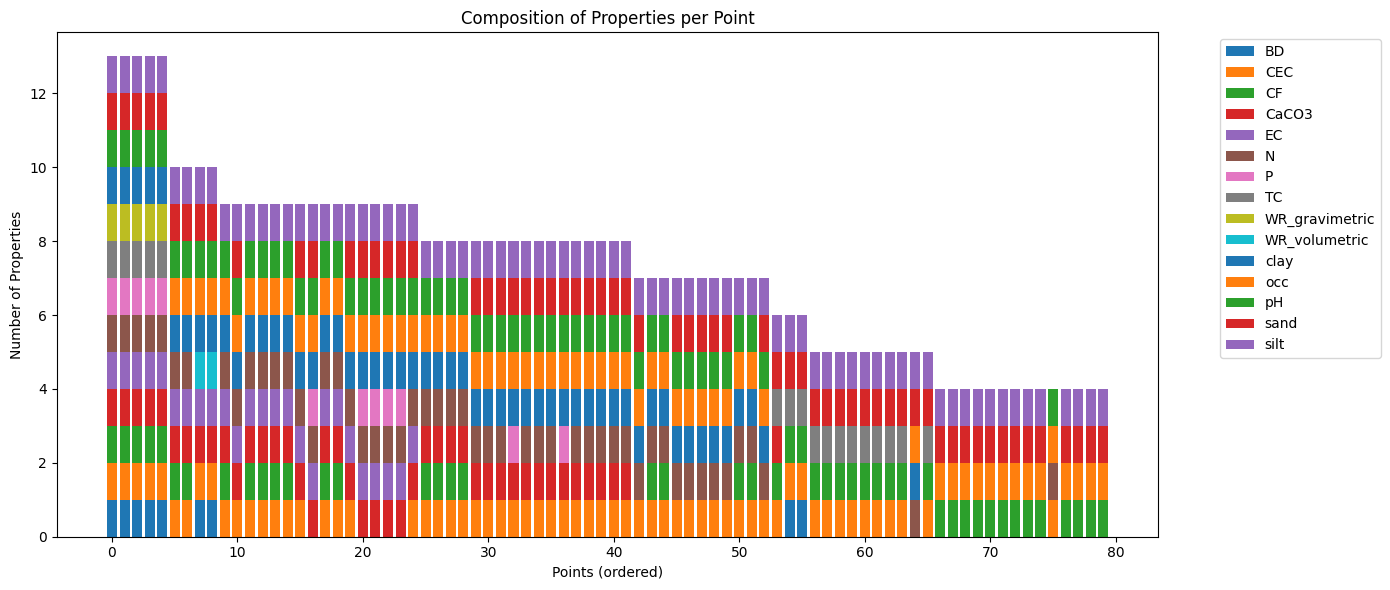

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

point_property_matrix = (
    df.groupby(["lat", "lon", "property"])
      .size()
      .unstack(fill_value=0)
)

point_property_matrix = (point_property_matrix > 0).astype(int)

point_property_matrix["n_properties"] = point_property_matrix.sum(axis=1)
point_property_matrix = point_property_matrix.sort_values(
    "n_properties", ascending=False
)

point_property_matrix = point_property_matrix.drop(columns=["n_properties"])



fig, ax = plt.subplots(figsize=(14,6))
bottom = None

for prop in point_property_matrix.columns:
    ax.bar(
        range(len(point_property_matrix)),
        point_property_matrix[prop],
        bottom=bottom,
        label=prop
    )
    if bottom is None:
        bottom = point_property_matrix[prop].values
    else:
        bottom = bottom + point_property_matrix[prop].values

ax.set_xlabel("Points (ordered)")
ax.set_ylabel("Number of Properties")
ax.set_title("Composition of Properties per Point")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

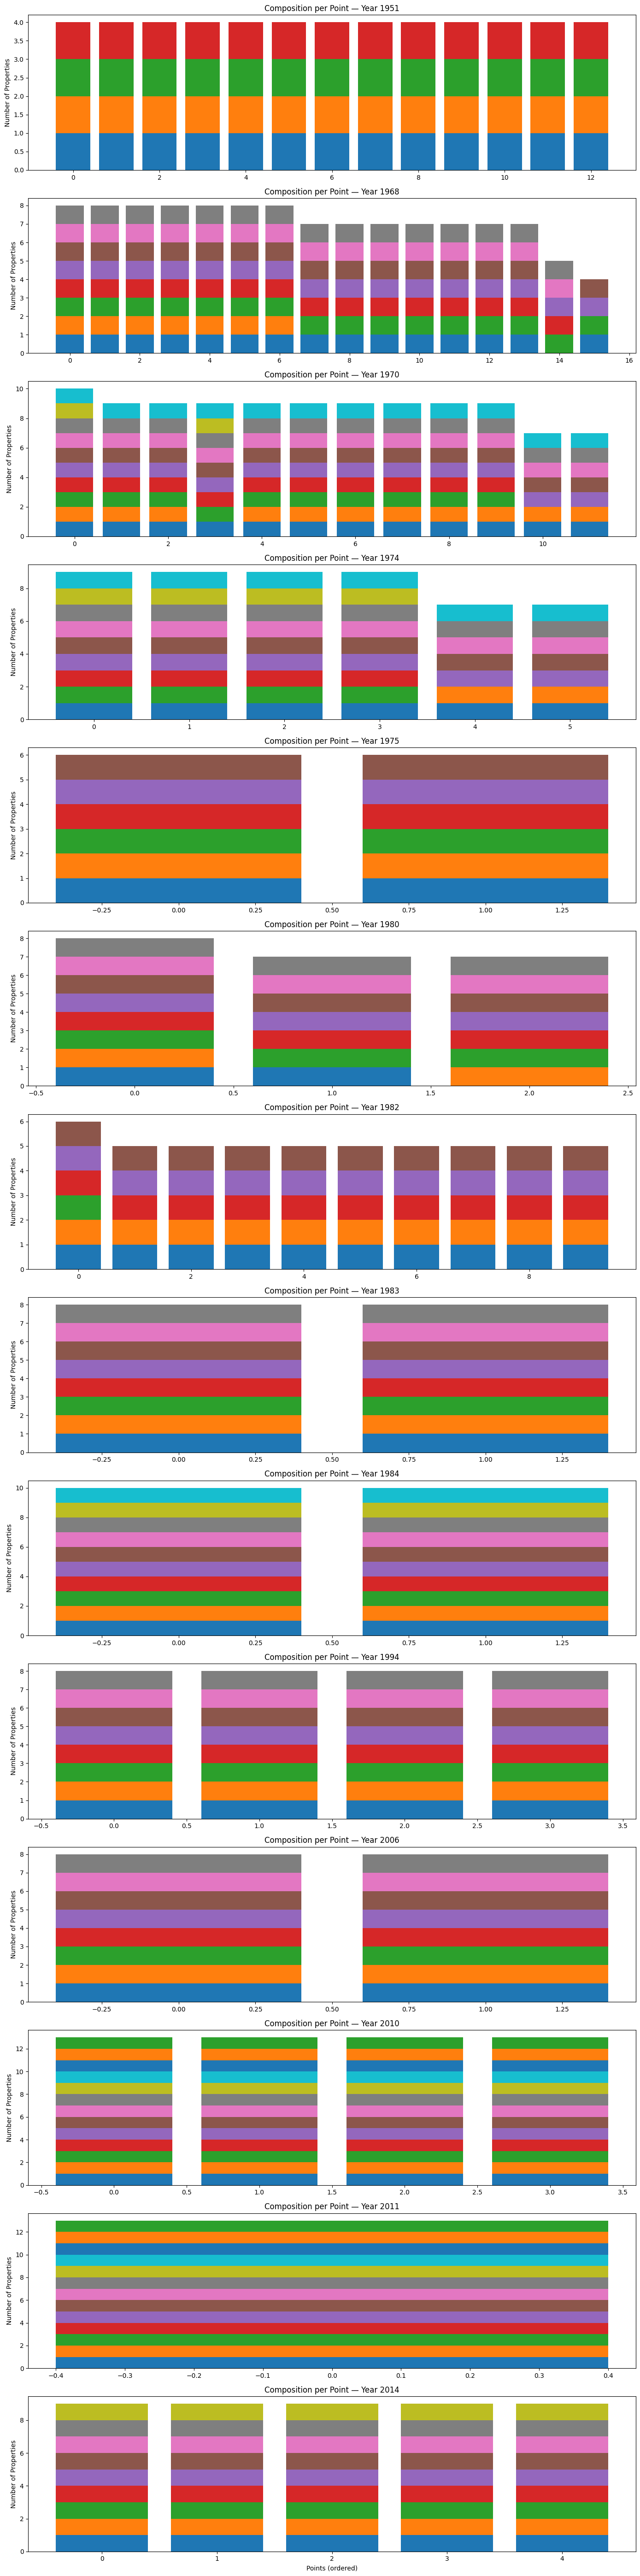

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

years = sorted(df["sampling_date"].unique())

fig, axes = plt.subplots(len(years), 1, figsize=(14, 4*len(years)))

if len(years) == 1:
    axes = [axes]

for ax, year in zip(axes, years):
    
    df_year = df[df["sampling_date"] == year]
    
    point_property_matrix = (
        df_year.groupby(["lat", "lon", "property"])
              .size()
              .unstack(fill_value=0)
    )
    
    point_property_matrix = (point_property_matrix > 0).astype(int)
    
    point_property_matrix["n_properties"] = point_property_matrix.sum(axis=1)
    point_property_matrix = point_property_matrix.sort_values(
        "n_properties", ascending=False
    )
    
    point_property_matrix = point_property_matrix.drop(columns=["n_properties"])
    
    bottom = None
    
    for prop in point_property_matrix.columns:
        ax.bar(
            range(len(point_property_matrix)),
            point_property_matrix[prop],
            bottom=bottom,
            label=prop
        )
        if bottom is None:
            bottom = point_property_matrix[prop].values
        else:
            bottom = bottom + point_property_matrix[prop].values
    
    ax.set_title(f"Composition per Point — Year {int(year)}")
    ax.set_ylabel("Number of Properties")

axes[-1].set_xlabel("Points (ordered)")

plt.tight_layout()
plt.show()

Now we know why some points have a lot of properties than others.

**1. La richesse en propriétés dépend fortement de l’année**

On observe clairement que :

* Certaines années (ex : 1970, 2010, 2011, 2014) présentent beaucoup plus de propriétés par point.

* D’autres années (1951, 1975, 1982…) ont moins de propriétés.

* Certaines campagnes sont très homogènes (mêmes propriétés sur tous les points).

* D’autres sont plus limitées.

La variabilité du nombre de propriétés par point est principalement expliquée par la campagne d’échantillonnage.


**2. Les campagnes historiques sont structurées**

Les années comme 1970 montrent :

* Beaucoup de propriétés simultanément.

* Une structure verticale cohérente.

* Plusieurs points très riches (jusqu’à 13 propriétés).

Cela correspond à une campagne complète et standardisée.


**3. Pourquoi certains points ont plus d’observations ?**

Parce que :
* Ils appartiennent à une campagne riche (ex: 1970).

* Ils ont plusieurs couches verticales.

* Ils ont plus de variables mesurées.

* Parfois ils ont plusieurs dates.

Ce n’est donc pas un problème de qualité des données,
mais une différence de protocole d’échantillonnage.

Count the number of campaigns per point

In [29]:
points_multi_campaign = (
    df.groupby(["lat", "lon"])["sampling_date"]
      .nunique()
      .reset_index(name="n_campaigns")
)

points_multi_campaign

,lat,lon,n_campaigns
0,28.116699,-16.650000,1
1,28.116699,-16.516701,1
2,28.133301,-16.566700,1
3,28.133301,-16.533300,1
4,28.316700,-16.450001,1
...,...,...,...
75,43.029527,-1.399638,1
76,43.100000,-2.366667,1
77,43.173110,-1.408973,1
78,43.250000,-6.000000,1


In [27]:
multi_campaign_points = points_multi_campaign[
    points_multi_campaign["n_campaigns"] > 1
]

print("Nombre de points multi-campagnes :", len(multi_campaign_points))

multi_campaign_points.head()

Nombre de points multi-campagnes : 2


,lat,lon,n_campaigns
19,37.4,-3.500000,2
29,38.8,-6.433333,2


In [30]:
points_with_years = (
    df.groupby(["lat", "lon"])["sampling_date"]
      .unique()
      .reset_index(name="years")
)

multi_campaign_details = points_with_years.merge(
    multi_campaign_points[["lat", "lon"]],
    on=["lat", "lon"],
    how="inner"
)

multi_campaign_details.head()

,lat,lon,years
0,37.4,-3.500000,"[1968.0, 1980.0]"
1,38.8,-6.433333,"[1970.0, 1974.0]"


In [31]:
points_multi_campaign["n_campaigns"].value_counts().sort_index()

n_campaigns
1    78
2     2
Name: count, dtype: int64